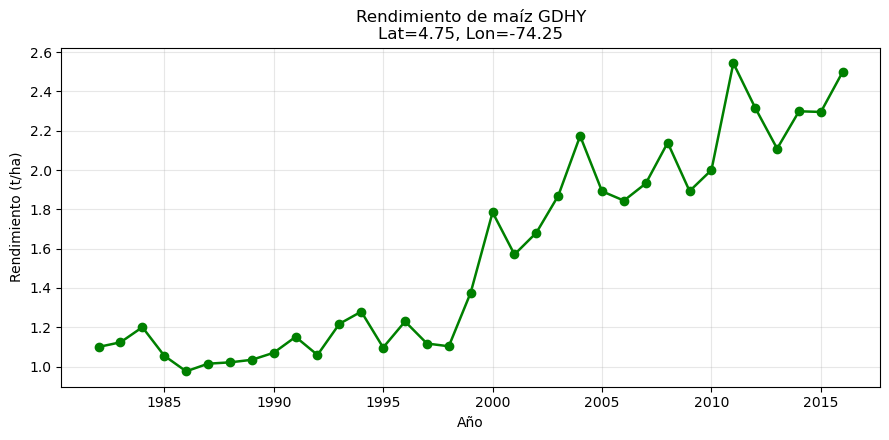

✅ Coordenadas reales del píxel seleccionado:
   Latitud: 4.75
   Longitud: -74.25


In [8]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import re

# Carpeta donde están los .nc4
DATA_DIR = r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\maize"

# Buscar los archivos por año
files = sorted(glob.glob(os.path.join(DATA_DIR, "yield_*.nc4")))
if not files:
    raise FileNotFoundError("No se encontraron archivos .nc4 en la carpeta indicada")

# Extraer año desde el nombre de archivo
years = [int(re.search(r"(\d{4})", os.path.basename(f)).group(1)) for f in files]

# Crear lista de DataArrays (uno por año)
datasets = []
for f, y in zip(files, years):
    ds = xr.open_dataset(f)
    da = ds["var"].expand_dims(time=[y])  # agregar coordenada temporal
    datasets.append(da)

# Concatenar todos los años en una sola dimensión temporal
ds_all = xr.concat(datasets, dim="time")

# Seleccionar un píxel en Colombia (Tolima aprox.)
lat_col = 4.5
lon_col = -74.5 + 360  # GDHY usa 0–360
serie = ds_all.sel(lat=lat_col, lon=lon_col, method="nearest")

# Graficar la serie
plt.figure(figsize=(9, 4.5))
plt.plot(serie["time"], serie.values, marker="o", lw=1.8, color="green")
plt.title(f"Rendimiento de maíz GDHY\nLat={float(serie.lat.values):.2f}, Lon={float(serie.lon.values)-360:.2f}")
plt.xlabel("Año")
plt.ylabel("Rendimiento (t/ha)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ Coordenadas reales del píxel seleccionado:")
print(f"   Latitud: {float(serie.lat.values):.2f}")
print(f"   Longitud: {float(serie.lon.values)-360:.2f}")


In [10]:
# ================== Setup (rutas y utils) ==================
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# === Rutas ===
QAQC_FILE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
DET_FILE  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\GDHY_maize_1981_2016_DETREND_clean.nc"
OUT_DIR   = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
os.makedirs(OUT_DIR, exist_ok=True)

# === Utilidad para longitudes ===
_wrap0360 = lambda lon: (lon + 360) % 360

# === Carga datasets ===
_ds_clean = xr.open_dataset(QAQC_FILE)
_ds_det   = xr.open_dataset(DET_FILE)

# Variables principales
_yield     = _ds_clean["yield_clean"]
_mask      = _ds_clean["qc_mask_final"]
_years     = _yield["time"].values.astype("int")

print(f"Dataset limpio: {_yield.shape}, años {min(_years)}–{max(_years)}")
print("Píxeles válidos QC:", int(_mask.sum().values))

# ================== Funciones ==================
def pixel_series(lat, lon, lon_is_180=True, normalize=False):
    """
    Devuelve un DataFrame con la serie de un píxel válido (según QC):
      - rendimiento limpio
      - tendencia lineal
      - anomalía (detrend)
    """
    lonq = _wrap0360(lon) if lon_is_180 else lon

    # Verificar si el píxel pasa la máscara QC
    qc_val = _mask.sel(lat=lat, lon=lonq, method="nearest").compute().item()
    if qc_val == 0:
        raise ValueError(f"❌ El píxel lat={lat}, lon={lon} no pasa la máscara QC (probablemente océano o sin cultivo).")

    # Serie de rendimiento limpio
    y = _yield.sel(lat=lat, lon=lonq, method="nearest").compute()

    # Series detrend
    a_pix = float(_ds_det["yield_trend_intercept"].sel(lat=lat, lon=lonq, method="nearest").compute().values)
    b_pix = float(_ds_det["yield_trend_slope"].sel(lat=lat, lon=lonq, method="nearest").compute().values)
    anom  = _ds_det["yield_detrended"].sel(lat=lat, lon=lonq, method="nearest").compute()

    years  = y["time"].values.astype("float32")
    trend  = a_pix + b_pix * years
    anom_v = anom.values

    if normalize:
        std = np.nanstd(anom_v)
        if std and np.isfinite(std) and std > 0:
            anom_v = anom_v / std

    return pd.DataFrame({
        "year": years.astype(int),
        "yield_clean": y.values,
        "trend": trend,
        "yield_anomaly": anom_v
    }), float(y.lat.values), float(y.lon.values)

def plot_pixel(lat, lon, lon_is_180=True, normalize=False, save_csv=False, save_png=False,
               title_prefix="Píxel"):
    """
    Grafica la serie temporal de un píxel (solo si pasa QC):
      - rendimiento limpio
      - tendencia lineal
      - anomalía (detrend)
    """
    try:
        df, lat0, lon0q = pixel_series(lat, lon, lon_is_180=lon_is_180, normalize=normalize)
    except ValueError as e:
        print(e)
        return None

    plt.figure(figsize=(8.6, 4.4))
    plt.plot(df["year"], df["yield_clean"], label="Rendimiento limpio", lw=1.6)
    plt.plot(df["year"], df["trend"],       label="Tendencia lineal",  lw=2.0)
    lab_anom = "Anomalía climática (z-score)" if normalize else "Anomalía climática (detrend)"
    plt.plot(df["year"], df["yield_anomaly"], label=lab_anom, lw=1.6)
    plt.xlabel("Año"); plt.ylabel("Rendimiento (t/ha)")
    plt.title(f"{title_prefix}: lat≈{lat0:.3f}, lon≈{lon0q:.3f} (lon 0–360)")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()

    stamp = f"{lat0:.3f}_{lon0q:.3f}"
    if save_csv:
        csv_path = os.path.join(OUT_DIR, f"pixel_{stamp}_{'z' if normalize else 'raw'}.csv")
        df.to_csv(csv_path, index=False)
        print("CSV guardado:", csv_path)
    if save_png:
        png_path = os.path.join(OUT_DIR, f"pixel_{stamp}_{'z' if normalize else 'raw'}.png")
        plt.savefig(png_path, dpi=150, bbox_inches="tight")
        print("PNG guardado:", png_path)

    plt.show()
    return df


Dataset limpio: (36, 360, 720), años 1981–2016
Píxeles válidos QC: 4530


❌ El píxel lat=-23.5, lon=-46.5 no pasa la máscara QC (probablemente océano o sin cultivo).


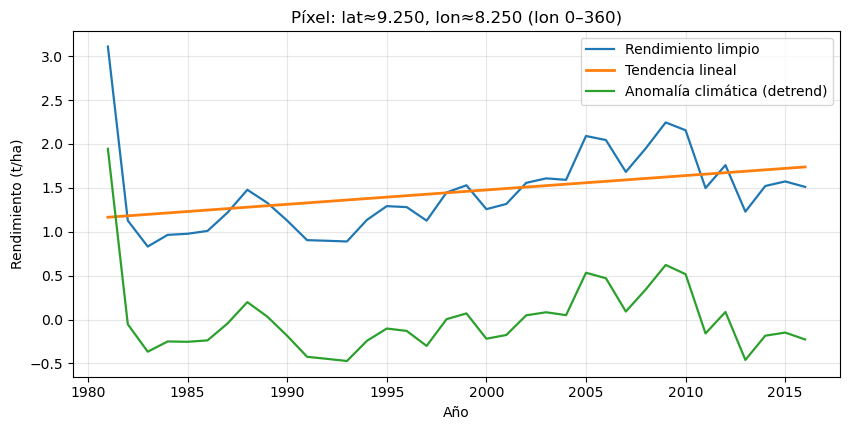

,year,yield_clean,trend,yield_anomaly
0,1981,3.109651,1.165079,1.944572
1,1982,1.127059,1.181452,-0.054393
2,1983,0.831232,1.197824,-0.366593
3,1984,0.964166,1.214197,-0.250031
4,1985,0.976804,1.230570,-0.253766
5,1986,1.009039,1.246943,-0.237904
6,1987,1.217079,1.263315,-0.046236
7,1988,1.477840,1.279688,0.198153
8,1989,1.329520,1.296061,0.033460
9,1990,1.126661,1.312433,-0.185772


In [16]:
# América del Sur (Brasil)
plot_pixel(-23.5, -46.5)

# África (Nigeria)
plot_pixel(9.0, 8.0)


# 🧠 Notas sobre el proceso de remoción de tendencia (GDHY)

## 1️⃣ Diferencia entre datasets originales y filtrados

El conjunto **GDHY (Global Dataset of Historical Yields)** entrega valores de rendimiento agrícola global (por ejemplo, maíz) en archivos anuales `yield_YYYY.nc4`.  
Estos archivos contienen un valor en **cada celda de la grilla**, pero **no todos los píxeles representan un cultivo real**.

| Dataset | Contenido | Máscara QC | Representa cultivo real |
|----------|------------|-------------|--------------------------|
| `yield_YYYY.nc4` (original) | Rendimiento interpolado global | ❌ No | ❌ No necesariamente |
| `maize_GDHY_1981_2016_QAQC.nc` | Rendimiento filtrado por calidad | ✅ Sí (`qc_mask_final`) | ✅ Sí |
| `GDHY_maize_1981_2016_DETREND_clean.nc` | Anomalías de rendimiento (tendencia removida) | ✅ Sí (`qc_mask_final`) | ✅ Sí |

---

## 2️⃣ Qué representan los valores del dataset original

Los valores en `yield_YYYY.nc4` se obtienen mediante **modelos estadísticos e interpolación global** a partir de datos FAO, USDA y satelitales (GAEZ, SPAM, etc.).  
Por esta razón:

- Cada píxel tiene un número, incluso si no hay cultivo.  
- Los valores fuera de las zonas agrícolas son **producto de interpolación**, no de medición ni simulación agronómica real.  
- Por eso, esos píxeles pueden mostrar tendencias o variaciones que **no representan cultivos**.

📉 Ejemplo: graficar el rendimiento cerca de Bogotá mostrará una serie numérica, pero esa celda no corresponde a maíz real según los mapas de uso del suelo.

---

## 3️⃣ Qué hace la máscara de calidad (QC)

La variable `qc_mask_final` filtra los píxeles válidos combinando tres criterios:

| Criterio | Descripción |
|-----------|-------------|
| **Cobertura agrícola (SPAM / MIRCA2000)** | Se elimina el píxel si el cultivo ocupa <5 % del área. |
| **Consistencia temporal** | Se eliminan píxeles con valores erráticos o faltantes entre años. |
| **Coincidencia con mapas de uso del suelo (MODIS/GLC2000)** | Se eliminan píxeles sin coincidencia agrícola. |

👉 Resultado:
- `1` → píxel válido (cultivo consistente de maíz 1981–2016)  
- `0` → píxel no confiable o sin cultivo

---

## 4️⃣ Por qué el mismo píxel a veces se puede graficar y otras no

- En el dataset original (`yield_YYYY.nc4`), el modelo **asigna un valor a todo el planeta** → se puede graficar cualquier coordenada.  
- En el dataset filtrado o detrended, solo se conservan los píxeles **validados como cultivo real** → si el píxel tiene `qc_mask_final = 0`, se descarta y lanza error.

Ejemplo:  
`lat=4.75°, lon=-74.25°` (zona de Bogotá) tiene valores en el dataset original, pero `qc_mask_final=0` (no cultivo de maíz) → no pasa la máscara.

---

## 5️⃣ Cómo identificar las zonas que realmente tienen cultivo

Para identificar las zonas agrícolas válidas (donde `qc_mask_final = 1`):

```python
import xarray as xr
import matplotlib.pyplot as plt

# Ruta al archivo QAQC (ajustar según tu estructura)
qc_path = r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
ds_qc = xr.open_dataset(qc_path)

# Variable de máscara
mask = ds_qc["qc_mask_final"]

# 1️⃣ Graficar solo Colombia
mask.sel(lat=slice(13, -5), lon=slice(285, 295)).plot()  # 285°–295° → -75° a -65°
plt.title("Máscara QC – píxeles válidos de maíz en Colombia (1 = cultivo)")
plt.show()

# 2️⃣ Verificar manualmente un píxel
lat, lon = 4.5, -72.5
val = mask.sel(lat=lat, lon=lon+360, method="nearest").item()
print(f"Píxel ({lat}, {lon}) QC = {val}")


# 🧩 Notas sobre la máscara de calidad (`qc_mask_final`) en el GDHY

## 1️⃣ Qué es la máscara QC

La variable `qc_mask_final` es una **máscara de calidad** incluida por los autores del **Global Dataset of Historical Yields (GDHY)**.  
No es creada por Python ni generada durante el procesamiento local, sino un producto oficial elaborado por el **equipo de investigación de la Universidad de Columbia y NASA GISS** (Anderson et al., 2019, 2020, 2023).

Esta máscara sirve para identificar **qué píxeles del dataset representan cultivos agrícolas reales** y cuáles deben descartarse por falta de fiabilidad.

---

## 2️⃣ Para qué sirve

El objetivo de la máscara QC es **garantizar que los análisis climáticos, agronómicos o de riesgo se realicen solo sobre áreas con cultivo confirmado**.

| Valor | Significado | Interpretación |
|--------|--------------|----------------|
| `1` | Píxel válido | Zona con cultivo consistente durante 1981–2016 |
| `0` | Píxel inválido | Zona sin cultivo o con datos inconsistentes |

Aplicar la máscara asegura que los análisis estadísticos no incluyan áreas urbanas, selvas, océanos o zonas donde el cultivo no está presente.

---

## 3️⃣ Cómo fue creada

La máscara `qc_mask_final` fue desarrollada por los autores del GDHY combinando **múltiples fuentes globales de información agrícola y de uso del suelo**, con el fin de validar espacial y temporalmente los píxeles agrícolas.

| Fuente | Rol en la máscara | Descripción |
|---------|------------------|--------------|
| **SPAM2020 (IFPRI)** | Validar dónde existe el cultivo | Indica la fracción del píxel dedicada a cada cultivo (maíz, arroz, trigo, etc.) |
| **MIRCA2000 (FAO / Univ. Frankfurt)** | Validar cuándo se cultiva | Define la estacionalidad y la superficie cultivada bajo riego o secano |
| **MODIS / GLC2000** | Validar uso del suelo | Confirma que el píxel pertenece a áreas agrícolas |
| **Control temporal (GDHY)** | Validar consistencia | Excluye píxeles con valores erráticos o faltantes entre años |

Un píxel se marca como **válido (`1`)** solo si cumple todos los criterios de coherencia espacial y temporal; de lo contrario, se marca como **inválido (`0`)**.

---

## 4️⃣ Qué pasa si se ignora la máscara

Si se analizan píxeles sin aplicar `qc_mask_final`, pueden aparecer valores numéricos en zonas **sin cultivo real**.  
Estos valores provienen de la interpolación global usada por el modelo GDHY, pero **no representan rendimientos agrícolas observados**.

Consecuencias de ignorar la máscara:
- Se introducen píxeles de ruido (selvas, ciudades, desiertos, etc.).
- Las correlaciones con índices climáticos (ENSO, MJO, precipitación, temperatura) se distorsionan.
- Se generan tendencias espurias no atribuibles a procesos agrícolas reales.

📉 En resumen:  
> Un valor en el dataset original no siempre implica que exista un cultivo real en ese píxel.

---

## 5️⃣ Cómo usar la máscara en Python

Ejemplo práctico de uso:

```python
import xarray as xr
import matplotlib.pyplot as plt

# Abrir dataset con máscara QC
path_qc = r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
ds_qc = xr.open_dataset(path_qc)

# Extraer la máscara
mask = ds_qc["qc_mask_final"]

# Verificar un píxel (Meta, Colombia)
lat, lon = 4.0, -72.5
valor_qc = mask.sel(lat=lat, lon=lon+360, method="nearest").item()
print(f"Píxel ({lat}, {lon}) QC =", valor_qc)

# Visualizar zonas válidas de cultivo en Colombia
mask.sel(lat=slice(13, -5), lon=slice(285, 295)).plot()
plt.title("Máscara QC – píxeles válidos de maíz (1 = cultivo real)")
plt.show()


# 🌍 Bases de datos agrícolas y de validación espacial utilizadas

Este apartado resume las principales bases de datos globales utilizadas en el proceso de análisis y validación del rendimiento agrícola y las áreas cultivadas.  
Todas son **fuentes científicas oficiales**, publicadas y revisadas por pares.

---

## 🌾 1️⃣ GDHY – *Global Dataset of Historical Yields*

**Institución responsable:**  
Lamont-Doherty Earth Observatory y NASA GISS, Columbia University, EE. UU.  

**Autores principales:**  
Weston Anderson, Walter Baethgen, Lisa Goddard, Liangzhi You, et al.  

**Publicaciones clave:**  
- Anderson et al. (2019). *Synchronous crop failures and climate-forced production variability.* *Science Advances, 5(7), eaaw1976.*  
- Anderson et al. (2023). *Climate variability and simultaneous breadbasket yield shocks as observed in long-term yield records.* *Agricultural and Forest Meteorology, 331, 109321.*

**Cobertura temporal:** 1981–2016  
**Resolución espacial:** 0.25° (~25 km)  
**Variables principales:**  
- `yield`: rendimiento por cultivo (t/ha)  
- `qc_mask_final`: máscara de calidad (1 = píxel válido, 0 = píxel no válido)  
- `time`, `lat`, `lon`

**Descripción técnica:**  
GDHY es un conjunto de datos global que combina información estadística (FAO, USDA, censos nacionales) y satelital (MODIS, AVHRR, GAEZ) para estimar **rendimientos históricos de maíz, arroz, trigo y soja**.  
Cada archivo anual representa una estimación interpolada del rendimiento medio por píxel.  

La versión **QAQC** incluye la variable `qc_mask_final`, que filtra los píxeles válidos de cultivo utilizando bases como SPAM y MIRCA2000, asegurando coherencia espacial y temporal.

**Uso recomendado:**  
- Análisis de rendimiento agrícola histórico.  
- Cálculo de tendencias, anomalías y correlaciones con índices climáticos (ENSO, MJO, etc.).  
- Identificación de pérdidas o shocks de productividad a escala global.

**Referencias:**  
- [https://zenodo.org/record/4316481](https://zenodo.org/record/4316481)  
- [https://data.nasaharvest.org/dataset/gdhy-v1-2](https://data.nasaharvest.org/dataset/gdhy-v1-2)

---

## 🌱 2️⃣ SPAM2020 – *Spatial Production Allocation Model*

**Institución responsable:**  
International Food Policy Research Institute (IFPRI) y CGIAR (2023).  

**Autores principales:**  
Liangzhi You, Stanley Wood, Ulrike Wood-Sichra, Wenbin Wu, Steffen Fritz.

**Publicación clave:**  
You, L., Wood, S., Wood-Sichra, U., Wu, W., & Fritz, S. (2023).  
*SPAM2020: Global gridded crop production dataset at 10 km resolution.* IFPRI.  
[https://mapspam.info](https://mapspam.info)  
[https://doi.org/10.7910/DVN/PRFF8V](https://doi.org/10.7910/DVN/PRFF8V)

**Cobertura temporal:** Año base 2020  
**Resolución espacial:** 0.083° (~10 km)  
**Cobertura geográfica:** Global  
**Cultivos incluidos:** 42 cultivos (maíz, arroz, trigo, soja, café, caña, etc.)

**Descripción técnica:**  
SPAM2020 estima la **distribución espacial de la producción agrícola** a nivel global, desagregando las estadísticas nacionales (FAO, ministerios de agricultura) sobre mapas de uso del suelo, clima, población y accesibilidad.  

Para cada cultivo, estima:
- **Área cosechada** (`harvested_area` o `area_fraction`),
- **Producción total** (`production`),
- **Rendimiento** (`yield`).

El modelo utiliza técnicas de **optimización espacial probabilística**, combinando censos agrícolas, mapas satelitales y restricciones biofísicas (riego, accesibilidad, altitud, etc.).

**Uso recomendado:**  
- Validar la ubicación de cultivos en el GDHY.  
- Calcular la proporción de área cultivada por píxel.  
- Definir máscaras agrícolas o dominios de análisis.

**Limitaciones:**  
- Representa un año promedio (no una serie temporal).  
- La precisión depende de la calidad del censo agrícola nacional.

**Referencias:**  
- [https://mapspam.info](https://mapspam.info)  
- [https://doi.org/10.7910/DVN/PRFF8V](https://doi.org/10.7910/DVN/PRFF8V)

---

## 💧 3️⃣ MIRCA2000 – *Monthly Irrigated and Rainfed Crop Areas*

**Institución responsable:**  
FAO y Universidad de Frankfurt (Alemania).  

**Autores principales:**  
Portmann, F. T., Siebert, S., & Döll, P. (2010).  
*MIRCA2000—Global monthly irrigated and rainfed crop areas around the year 2000: A new high-resolution dataset for agricultural and hydrological modeling.*  
*Global Biogeochemical Cycles, 24(1), GB1011.*  
[https://doi.org/10.1029/2008GB003435](https://doi.org/10.1029/2008GB003435)

**Cobertura temporal:** Año base 2000 (media 1998–2002)  
**Resolución espacial:** 0.083° (~10 km)  
**Cobertura geográfica:** Global  
**Variables principales:**  
- Área cultivada mensual bajo **riego** (`irrigated_area`)  
- Área cultivada mensual bajo **secano** (`rainfed_area`)

**Descripción técnica:**  
MIRCA2000 combina estadísticas agrícolas, datos de uso del suelo, y balances hídricos para estimar mensualmente la superficie cultivada bajo riego y secano para 26 cultivos principales.  
Es un dataset clave para analizar la **estacionalidad de los cultivos** y la disponibilidad de agua agrícola.

**Uso recomendado:**  
- Validar los períodos de siembra y cosecha por región.  
- Distinguir entre agricultura de riego y de secano.  
- Calibrar calendarios agrícolas o fases fenológicas.

**Limitaciones:**  
- Año base 2000 (no serie temporal).  
- No distingue entre variedades de un mismo cultivo.

**Referencias:**  
- [https://www.uni-frankfurt.de/45218031/MIRCA2000](https://www.uni-frankfurt.de/45218031/MIRCA2000)  
- [https://doi.org/10.1029/2008GB003435](https://doi.org/10.1029/2008GB003435)

---

## 🧠 4️⃣ Relación entre las tres bases

| Dataset | Fuente | Tipo de información | Rol metodológico |
|----------|---------|---------------------|------------------|
| **GDHY** | Columbia Univ. / NASA GISS | Rendimientos agrícolas históricos (1981–2016) | Base principal de análisis |
| **SPAM2020** | IFPRI / CGIAR | Distribución espacial y fracción de área cultivada | Validación espacial de áreas agrícolas |
| **MIRCA2000** | FAO / Univ. Frankfurt | Calendario y extensión mensual (riego/secano) | Validación temporal (estacionalidad de cultivos) |

En el proceso de construcción del GDHY, los autores usaron SPAM y MIRCA2000 como **capas de referencia** para definir la máscara de calidad (`qc_mask_final`).  
Solo los píxeles que coincidían con áreas agrícolas estables y consistentes entre estas bases fueron marcados como válidos (`qc_mask_final = 1`).

---

## 📚 5️⃣ Referencias bibliográficas

- Anderson, W. B., Seager, R., Baethgen, W., Cane, M., & You, L. (2019). *Synchronous crop failures and climate-forced production variability.* **Science Advances, 5(7), eaaw1976.** [https://doi.org/10.1126/sciadv.aaw1976](https://doi.org/10.1126/sciadv.aaw1976)

- Anderson, W. B., Baethgen, W., Capitanio, F., Ciais, P., Cook, B. I., Goddard, L., & You, L. (2023). *Climate variability and simultaneous breadbasket yield shocks as observed in long-term yield records.* **Agricultural and Forest Meteorology, 331, 109321.** [https://doi.org/10.1016/j.agrformet.2023.109321](https://doi.org/10.1016/j.agrformet.2023.109321)

- You, L., Wood, S., Wood-Sichra, U., Wu, W., & Fritz, S. (2023). *SPAM2020: Global gridded crop production dataset at 10 km resolution.* **International Food Policy Research Institute (IFPRI).** [https://mapspam.info](https://mapspam.info) – [https://doi.org/10.7910/DVN/PRFF8V](https://doi.org/10.7910/DVN/PRFF8V)

- Portmann, F. T., Siebert, S., & Döll, P. (2010). *MIRCA2000—Global monthly irrigated and rainfed crop areas around the year 2000.* **Global Biogeochemical Cycles, 24(1), GB1011.** [https://doi.org/10.1029/2008GB003435](https://doi.org/10.1029/2008GB003435)


In [24]:
"""
===========================================================
RECONSTRUCCIÓN DEL RENDIMIENTO DETRENDIDO (GDHY - MAIZE)
===========================================================

Autor:        Paola A. Ruiz F.
Fecha:        2025-10-29
Versión:      1.0
Objetivo:     Reconstruir la variable `yield_detrended`
              a partir de los coeficientes de tendencia
              (intercepto y pendiente) y del rendimiento limpio.

Descripción:
  En el archivo original GDHY_maize_1981_2016_DETREND_clean.nc,
  los coeficientes `yield_trend_intercept` y `yield_trend_slope`
  existen, pero la variable `yield_detrended` está casi vacía (98 % NaN).
  Este script reconstruye el rendimiento detrendido y guarda
  un archivo corregido listo para correlaciones climáticas.

===========================================================
"""

# ================== LIBRERÍAS ==================
import os
import numpy as np
import xarray as xr

# ================== RUTAS ==================
QAQC_FILE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
DET_FILE  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\GDHY_maize_1981_2016_DETREND_clean.nc"
OUT_FILE  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\GDHY_maize_1981_2016_DETREND_fixed.nc"

# ================== CARGA DE DATOS ==================
print("📦 Cargando datasets...")

# Rendimiento limpio (QAQC)
clean = xr.open_dataset(QAQC_FILE)["yield_clean"]

# Detrend con coeficientes
det = xr.open_dataset(DET_FILE)
a = det["yield_trend_intercept"]
b = det["yield_trend_slope"]

print("✅ Datos cargados correctamente.")
print("Dimensiones del rendimiento limpio:", clean.shape)
print("Años:", clean["time"].values[0], "→", clean["time"].values[-1])

# ================== RECONSTRUCCIÓN ==================
print("🔧 Reconstruyendo la serie detrendida...")

# Broadcasting automático de dimensiones (time, lat, lon)
years = clean["time"]
trend = a + b * years.astype("float32")

# Remover la tendencia
yield_detrended = clean - trend

# ================== APLICAR MÁSCARA QC ==================
mask_ds = xr.open_dataset(QAQC_FILE)
if "qc_mask_final" in mask_ds:
    mask = mask_ds["qc_mask_final"]
    yield_detrended = yield_detrended.where(mask == 1)
    print("🟢 Máscara QC aplicada.")

# ================== CREAR DATASET NUEVO ==================
det_fixed = xr.Dataset({
    "yield_detrended_fixed": yield_detrended,
    "yield_trend_intercept": a,
    "yield_trend_slope": b
})

# Atributos
det_fixed["yield_detrended_fixed"].attrs.update({
    "description": "Rendimiento agrícola detrendido reconstruido (tendencia removida)",
    "units": "t/ha",
    "method": "yield_clean - (a + b * year)",
    "source": "Reconstruido a partir de coeficientes GDHY_detrend_clean.nc y yield_clean de GDHY_QAQC."
})

# ================== GUARDAR ARCHIVO ==================
det_fixed.to_netcdf(OUT_FILE, mode="w", format="NETCDF4", compute=True)
print(f"✅ Dataset reconstruido guardado en:\n{OUT_FILE}")

# ================== VERIFICACIÓN ==================
y = det_fixed["yield_detrended_fixed"]
pct_nan = float(np.isnan(y).mean().values) * 100
print(f"Porcentaje de NaN después de reconstrucción: {pct_nan:.2f} %")

# Verificar variabilidad en un píxel agrícola
lat_test, lon_test = 23.25, 59.25
rend_pixel = y.sel(lat=lat_test, lon=lon_test, method="nearest")
print(f"STD del píxel ({lat_test}°, {lon_test}°):", float(rend_pixel.std().values))
print("✅ Proceso completado correctamente.")


📦 Cargando datasets...
✅ Datos cargados correctamente.
Dimensiones del rendimiento limpio: (36, 360, 720)
Años: 1981 → 2016
🔧 Reconstruyendo la serie detrendida...
🟢 Máscara QC aplicada.
✅ Dataset reconstruido guardado en:
C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\GDHY_maize_1981_2016_DETREND_fixed.nc
Porcentaje de NaN después de reconstrucción: 98.25 %
STD del píxel (23.25°, 59.25°): nan
✅ Proceso completado correctamente.


C:\Users\paola\anaconda3\envs\geo2env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning:

Degrees of freedom <= 0 for slice.



In [25]:
import xarray as xr
import numpy as np

clean = xr.open_dataset(
    r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
)["yield_clean"]

print("Dimensiones:", clean.shape)
print("Porcentaje de NaN:", float(np.isnan(clean).mean().values) * 100, "%")
print("Ejemplo de valor promedio:", float(clean.mean(skipna=True).values))


Dimensiones: (36, 360, 720)
Porcentaje de NaN: 98.25231481481481 %
Ejemplo de valor promedio: 3.362060785293579


In [26]:
mask_ds = xr.open_dataset(
    r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
)
mask = mask_ds["qc_mask_final"]

print("Máscara - proporción de 1s:", float(mask.mean().values))


Máscara - proporción de 1s: 0.01747685185185185


In [27]:
lat_test, lon_test = 23.25, 59.25  # el mismo que usaste
y = clean.sel(lat=lat_test, lon=lon_test, method="nearest")
print(y)
print("Valores únicos:", np.unique(y.values))


<xarray.DataArray 'yield_clean' (time: 36)> Size: 144B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)
Coordinates:
    lon      float64 8B 59.25
    lat      float64 8B 23.25
  * time     (time) int64 288B 1981 1982 1983 1984 1985 ... 2013 2014 2015 2016
Valores únicos: [nan]


In [1]:
# ============================================================
#   REMOCIÓN DE TENDENCIA LINEAL (DETREND) PARA RENDIMIENTOS
# ============================================================

import xarray as xr
import numpy as np
from scipy.stats import linregress
import os

# ========= RUTAS ==========
DATA_DIR = r"C:\Users\paola\Tesis\02_Procesados\GDHY_bruto"
OUT_DIR  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
os.makedirs(OUT_DIR, exist_ok=True)

cultivos = ["maize", "rice", "soybean", "wheat"]

# ========= FUNCIÓN PARA EL DETREND ==========
def detrend_1d(y, x):
    """Elimina la tendencia lineal de una serie 1D ignorando NaN."""
    mask = np.isfinite(y)
    if mask.sum() < 3:
        return np.full_like(y, np.nan)
    slope, intercept, _, _, _ = linregress(x[mask], y[mask])
    return y - (slope * x + intercept)

# ========= PROCESAMIENTO POR CULTIVO ==========
for cultivo in cultivos:
    print(f"\n==================== {cultivo.upper()} ====================")
    file_path = os.path.join(DATA_DIR, f"{cultivo}_yield_1981_2016.nc")
    if not os.path.exists(file_path):
        print(f"⚠️ No se encontró el archivo {file_path}")
        continue

    # 1️⃣ Cargar datos
    da = xr.open_dataarray(file_path)
    years = da["time"].values.astype(float)

    # 2️⃣ Aplicar detrend
    print("🧮 Eliminando tendencia...")
    da_detrend = xr.apply_ufunc(
        detrend_1d,
        da,
        years,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    da_detrend = da_detrend.assign_coords(time=da.time)
    da_detrend.attrs.update({
        "description": "Rendimiento agrícola con tendencia lineal removida",
        "source": "GDHY v1.3 (Paola Ruiz, 2025)",
        "method": "linregress per pixel (1981–2016)"
    })

    # 3️⃣ Guardar archivo detrendido
    out_path = os.path.join(OUT_DIR, f"{cultivo}_yield_1981_2016_DETREND.nc")
    da_detrend.to_netcdf(out_path)
    print(f"✅ Guardado: {out_path}")

    # 4️⃣ Confirmación rápida
    print("   Dimensiones:", da_detrend.dims, "| Valores válidos:", np.isfinite(da_detrend).sum().item())



==================== MAIZE ====================
🧮 Eliminando tendencia...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND.nc
   Dimensiones: ('lat', 'lon', 'time') | Valores válidos: 516823

==================== RICE ====================
🧮 Eliminando tendencia...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND.nc
   Dimensiones: ('lat', 'lon', 'time') | Valores válidos: 328867

==================== SOYBEAN ====================
🧮 Eliminando tendencia...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND.nc
   Dimensiones: ('lat', 'lon', 'time') | Valores válidos: 212568

==================== WHEAT ====================
🧮 Eliminando tendencia...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND.nc
   Dimensiones: ('lat', 'lon', 'time') | Valores válidos: 432924
